In [624]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.distributions as dist
import src.fitting as fit
import src.formulas as fo
import src.figure as fi

from scipy.stats import kstest
  
import numpy as np


%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data generation
Note that this notebook assumes that a certain amount of samples drawn from the distribution represents a single measurement. In other words, ergodicity is assumed.
Note that this notebook assumes that a cluster of 4 fluorophores is fully described with the 12 parameters - i.e., that the physical factors determining the parameters are constant for a cluster.

In [701]:
# use this set of parameters throughout the notebook
lambdas1 = [6.3, 5.4, 4, 3.7]
lambdas2 = [6, 3.7, 2e-2, 8e-4]
pis = [0.975, 0.93, 0.73, 0.01]
parameters = [[lambdas1, lambdas2], pis]
PFM = dist.Photoswitching_fingerprint_model(*parameters)
pdf_tar = PFM.pdf
cdf_tar = PFM.cdf

## Numerical inversion
The interpolating polynomials have to be computed in a setup step. However, it only works for distributions with bounded domain; for distributions with unbounded domain the tails are cut off such that the probability for the tail regions is small compared to the given u-resolution.

The goal of sampling is expected to produce bounded samples, hence using the truncated distribution (which, indeed, is bounded) would be sufficient.

#### Hermite Inverse CDF HINV

In [626]:
from scipy.stats.sampling import NumericalInverseHermite

In [702]:
class ps_fingerprint():
    def cdf(x):
        return cdf_tar(x)
    def pdf(x):
        return pdf_tar(x, order=0)
    def dpdf(x):
        return pdf_tar(x, order=1)

In [703]:
distr = NumericalInverseHermite(ps_fingerprint, order=3, domain=[0, np.inf], u_resolution=1e-8)

In [704]:
samples = distr.rvs(size=int(1e6))

array([[<Axes: title={'center': 'HINV'}, xlabel='x', ylabel='y'>]],
      dtype=object)

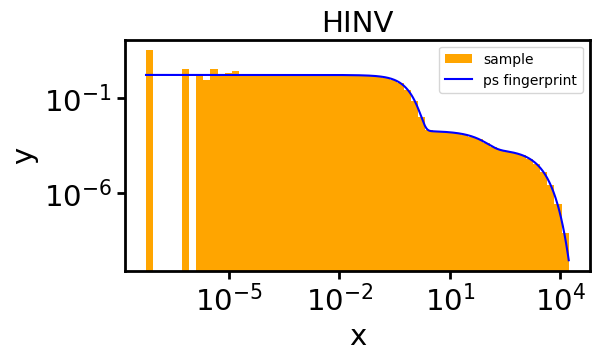

In [706]:
x = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 1000)
bins = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 60)
ax = fi.universal_figure(type_='hist', data=[samples], bins=bins, color='orange', ylabel='counts', xlabel='x', 
                         title='HINV', density=True, label='sample')
fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint', axes=ax, legend=True, color='blue',
                    xscale='log', yscale='log')

In [707]:
p = kstest(samples, cdf_tar)[1]
print(f'if p value > 0.05, sampling was successfull. p-value: {p}')
if p < 0.05:
    print('Sampling was not successfull.')
else:
    print('Sampling was successfull.')

if p value > 0.05, sampling was successfull. p-value: 0.24985405437396524
Sampling was successfull.


In [668]:
from scipy.stats import norm, truncnorm

The drawn times are essentially times at which photon detection happens. However, a subset of drawn times does not represent a single run, since in an experiment, many photons appear in short time intervals, spaced by long OFF times. I.e., instead of drawing 50 photons happening within a few ms, one would draw 1 photon every other ms. If the subset is small enough, one could interpret it as ON state occurrences, however this is also not true because the number of photons emitted by an ON state can differ depending on the number of living fluorophores of the system, as some energy transfers (e.g., RISC) can change the number of photons per ON state. Nevertheless, this effect is probably neglectable. What can change more significantly depending on the number of living fluorophores is the duration of an ON state and the number of photons per frame or time. 

In [696]:
def actual_trunc_norm(loc, scale, a, b, size):
    a = (a - loc) / scale
    b = (b - loc) / scale
    return truncnorm.rvs(loc=loc, scale=scale, a=a, b=b, size=size)

def generate_n_cluster_ps_fingerprint_4f(
        n,
        mean_on_states, 
        domain,
        parameters):
    """
    n : int
        number of clusters.
    number_fluorophores : int
        number of fluorophores per cluster.
    mean_on_states : float
        mean number of ON states per cluster.
    domain : tuple
        start and end time of the measurement.
    parameters : 2-D array_like
    """
    l1 = np.array(parameters[0][0])
    l2 = np.array(parameters[0][1])
    p = np.array(parameters[1])
    l1_1 = norm.rvs(loc=l1[0], scale=l1[0]/10, size=n)
    l2_1 = actual_trunc_norm(loc=l1[1], scale=l1[1]/10, a=0, b=l1_1, size=n)
    l3_1 = actual_trunc_norm(loc=l1[2], scale=l1[2]/10, a=0, b=l2_1, size=n)
    l4_1 = actual_trunc_norm(loc=l1[3], scale=l1[3]/10, a=0, b=l3_1, size=n)
    l4_2 = actual_trunc_norm(loc=l2[3], scale=l2[3]/10, a=0, b=l4_1, size=n)
    l3_2 = actual_trunc_norm(loc=l2[2], scale=l2[2]/10, a=l4_2, b=l3_1, size=n)
    l2_2 = actual_trunc_norm(loc=l2[1], scale=l2[1]/10, a=l3_2, b=l2_1, size=n)
    l1_2 = actual_trunc_norm(loc=l2[0], scale=l2[0]/10, a=l2_2, b=l1_1, size=n)
    pi1 = actual_trunc_norm(loc=p[0], scale=p[0]/10, a=0, b=1, size=n)
    pi2 = actual_trunc_norm(loc=p[1], scale=p[1]/10, a=0, b=pi1, size=n)
    pi3 = actual_trunc_norm(loc=p[2], scale=p[2]/10, a=0, b=pi2, size=n)
    pi4 = actual_trunc_norm(loc=p[3], scale=p[3]/10, a=0, b=pi3, size=n)
    parameters = np.array([l1_1, l2_1, l3_1, l4_1, l1_2, l2_2, l3_2, l4_2, pi1, pi2, pi3, pi4])
    mean_on_states_all = norm.rvs(loc=mean_on_states, scale=mean_on_states/10, size=n)
    all_samples = []
    for i, mean_on_states in enumerate(mean_on_states_all):
        lambdas1 = parameters[:4, i]
        lambdas2 = parameters[4:8, i]
        pis = parameters[8:, i]
        ps_fingerprint = dist.Photoswitching_fingerprint_model(lambdas=[lambdas1, lambdas2], pis_orig=pis, domain=domain)
        distr = NumericalInverseHermite(ps_fingerprint, order=3, domain=domain, u_resolution=1e-10)
        samples = distr.rvs(size=int(mean_on_states))
        all_samples.append(samples)
    return all_samples

In [699]:
all_samples = generate_n_cluster_ps_fingerprint_4f(10, int(1e5), (0, 300), parameters=parameters)

eCDF is the empirical cumulative distribution function. It is the correct description also for the experimental photoswitching fingerprints.

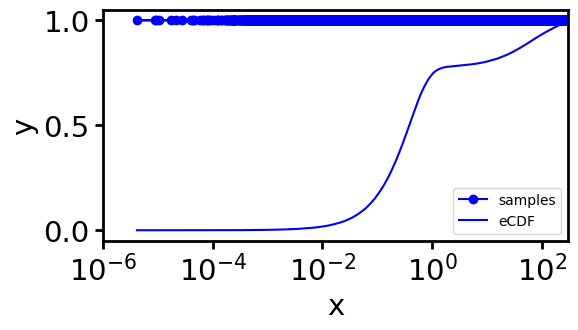

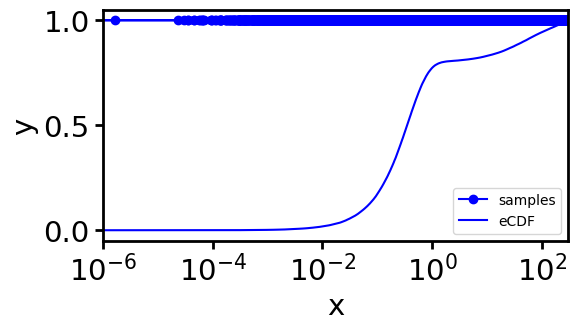

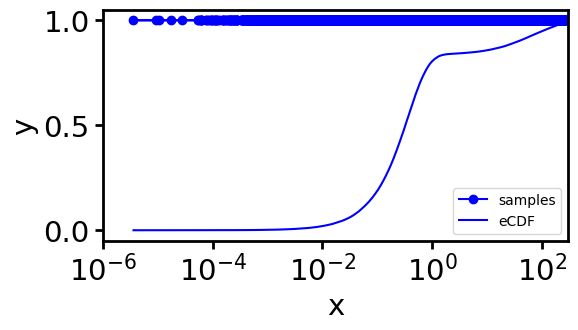

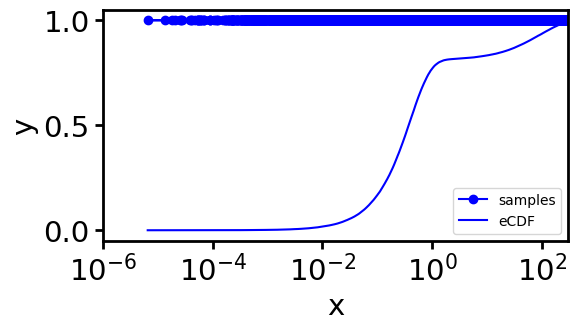

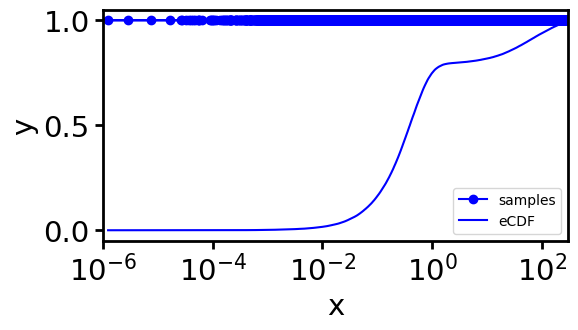

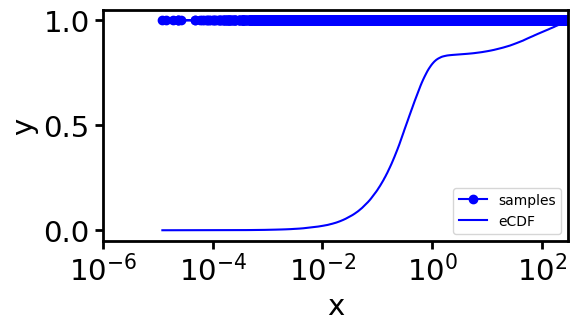

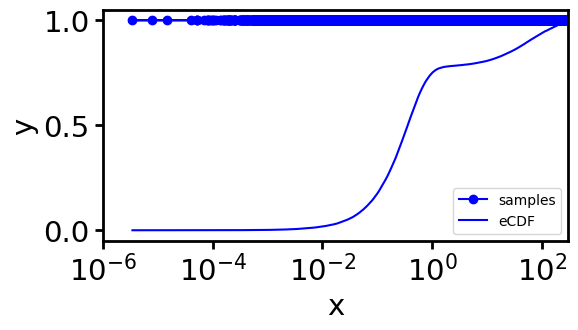

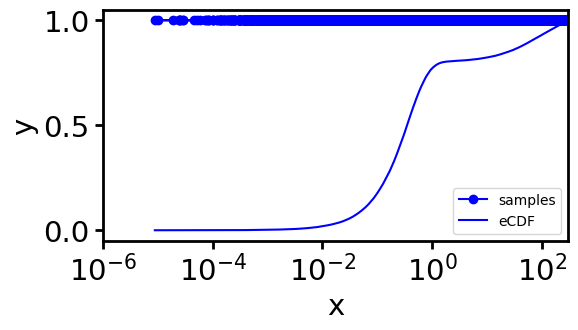

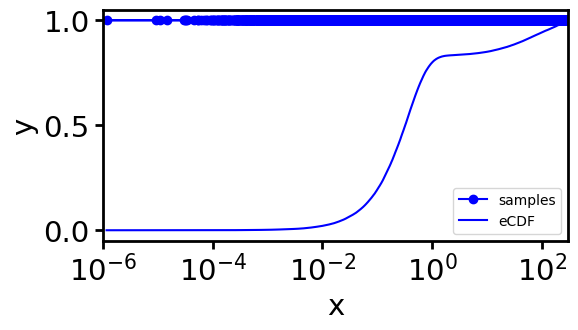

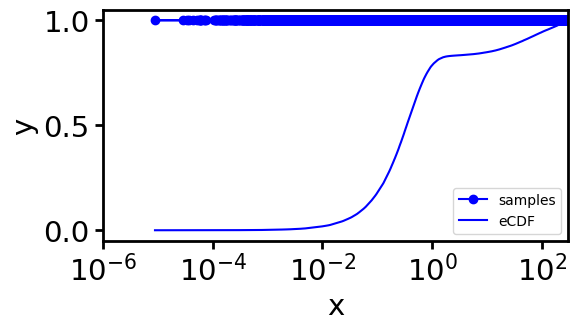

: 

In [ ]:
for samples in all_samples:
    cumsum = np.cumsum(np.ones_like(samples))
    ecdf = cumsum / cumsum[-1]
    ax = fi.universal_figure(data=[samples, np.ones_like(samples)], marker='o', label='samples', xlim=[1e-6, 300])
    fi.universal_figure(data=[np.sort(samples), ecdf], axes=ax, label='eCDF', legend=True, xscale='log')